# Inspect LeRobot Recording

Visualize a recorded dataset: timing, joint states, EE pose, action, and gripper over time.

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

LEROBOT_CACHE = Path.home() / ".cache/huggingface/lerobot"

# ---- Configure here ----
REPO_ID = "teleop_ep003"
EPISODE_IDX = 0
# ------------------------

In [5]:
# Load dataset
ds = LEROBOT_CACHE / REPO_ID
info = json.loads((ds / "meta/info.json").read_text())
fps = info["fps"]

parts = sorted((ds / "data").rglob("*.parquet"))
df = pd.concat([pd.read_parquet(p) for p in parts])
ep = df[df.episode_index == EPISODE_IDX].sort_values("frame_index").reset_index(drop=True)

print(f"Dataset: {REPO_ID}  |  Episode: {EPISODE_IDX}")
print(f"Frames: {len(ep)}  |  FPS: {fps}  |  Duration: {len(ep)/fps:.2f} s")
print(f"Columns: {list(ep.columns)}")

Dataset: camera_test_wmocap6  |  Episode: 0
Frames: 189  |  FPS: 20  |  Duration: 9.45 s
Columns: ['observation.state.joints', 'observation.state.cartesian', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']


In [6]:
# Build time axis from timestamps
ts = ep["timestamp"].values
t = ts - ts[0]  # seconds from start

## 1. Frame timing

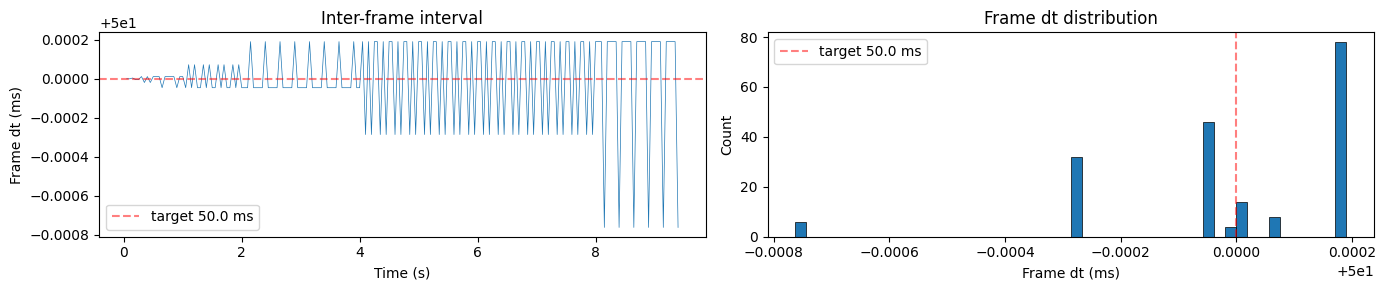

dt  mean=50.00 ms  std=0.00 ms  min=50.00 ms  max=50.00 ms


In [7]:
dt = np.diff(t) * 1000  # ms

fig, axes = plt.subplots(1, 2, figsize=(14, 3))

axes[0].plot(t[1:], dt, linewidth=0.5)
axes[0].axhline(1000 / fps, color="r", linestyle="--", alpha=0.5, label=f"target {1000/fps:.1f} ms")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Frame dt (ms)")
axes[0].set_title("Inter-frame interval")
axes[0].legend()

axes[1].hist(dt, bins=50, edgecolor="black", linewidth=0.5)
axes[1].axvline(1000 / fps, color="r", linestyle="--", alpha=0.5, label=f"target {1000/fps:.1f} ms")
axes[1].set_xlabel("Frame dt (ms)")
axes[1].set_ylabel("Count")
axes[1].set_title("Frame dt distribution")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"dt  mean={dt.mean():.2f} ms  std={dt.std():.2f} ms  min={dt.min():.2f} ms  max={dt.max():.2f} ms")

## 2. Joint states

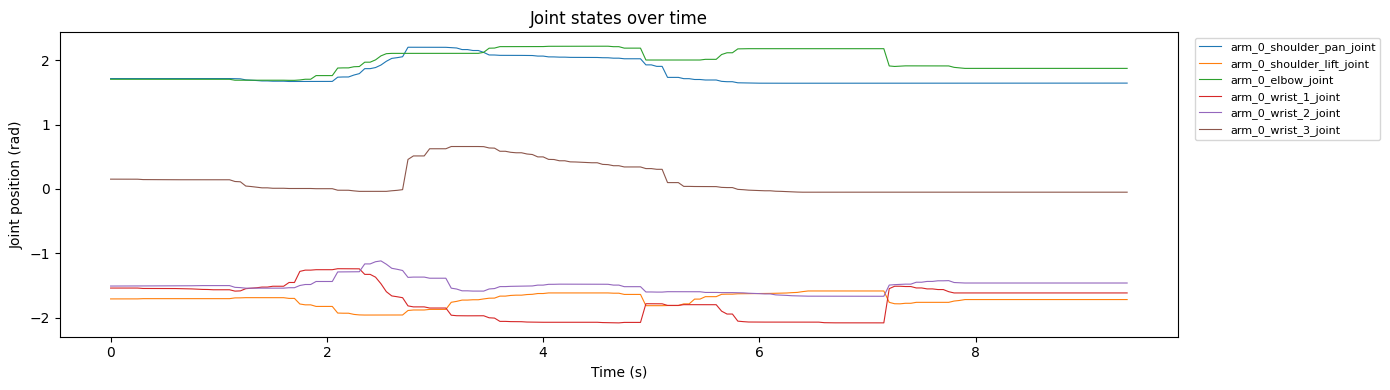

In [8]:
if "observation.state.joints" in ep.columns:
    joints = np.stack(ep["observation.state.joints"].values)
    joint_names = info["features"].get("observation.state.joints", {}).get("names", 
        [f"j{i}" for i in range(joints.shape[1])])

    fig, ax = plt.subplots(figsize=(14, 4))
    for i in range(joints.shape[1]):
        ax.plot(t, joints[:, i], label=joint_names[i], linewidth=0.8)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Joint position (rad)")
    ax.set_title("Joint states over time")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No observation.state.joints in dataset")

## 3. End-effector pose (current_pose)

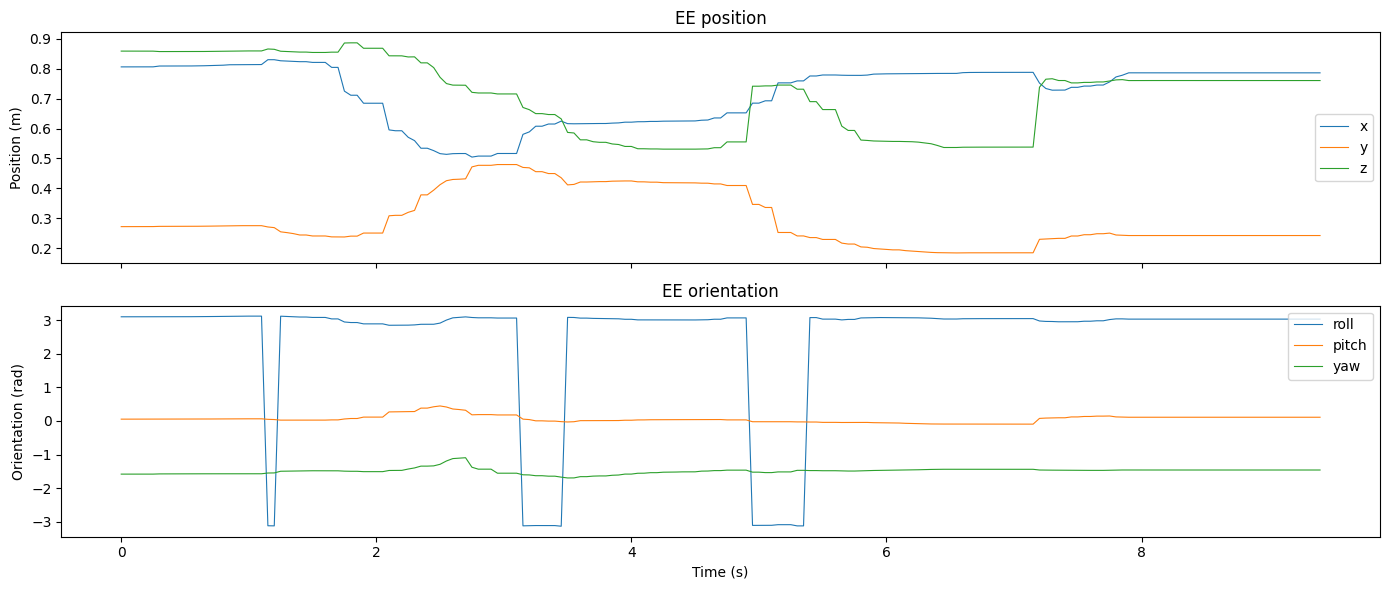

In [9]:
if "observation.state.cartesian" in ep.columns:
    cart = np.stack(ep["observation.state.cartesian"].values)
    cart_names = ["x", "y", "z", "roll", "pitch", "yaw"]

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

    for i in range(3):
        axes[0].plot(t, cart[:, i], label=cart_names[i], linewidth=0.8)
    axes[0].set_ylabel("Position (m)")
    axes[0].set_title("EE position")
    axes[0].legend()

    for i in range(3, 6):
        axes[1].plot(t, cart[:, i], label=cart_names[i], linewidth=0.8)
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("Orientation (rad)")
    axes[1].set_title("EE orientation")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("No observation.state.cartesian in dataset")

## 4. Action (target_pose + gripper)

Action dim: 7


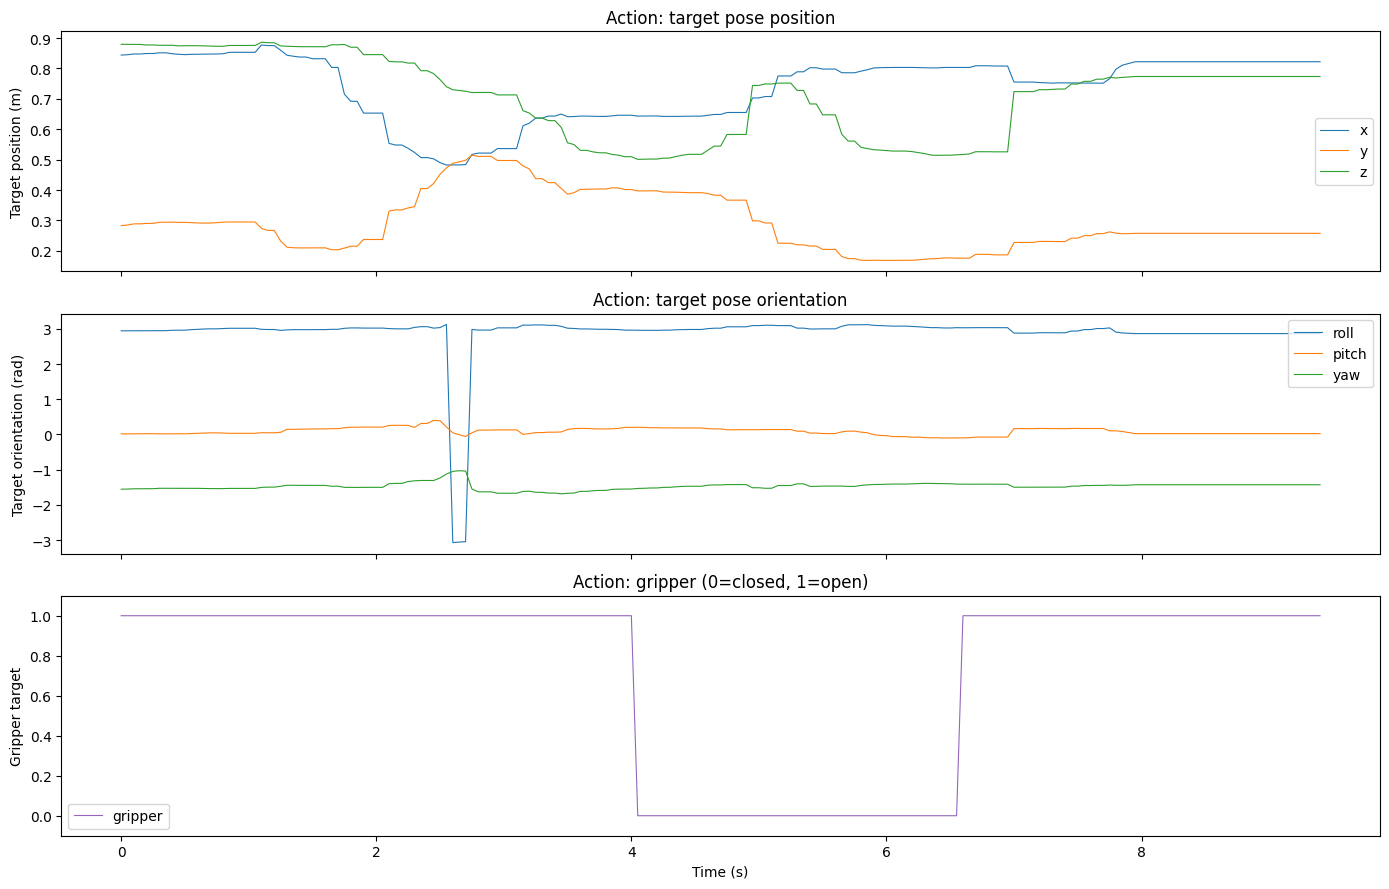

In [10]:
act = np.stack(ep["action"].values)
act_dim = act.shape[1]
print(f"Action dim: {act_dim}")

if act_dim >= 7:
    act_names = ["x", "y", "z", "roll", "pitch", "yaw", "gripper"]

    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

    # Position
    for i in range(3):
        axes[0].plot(t, act[:, i], label=act_names[i], linewidth=0.8)
    axes[0].set_ylabel("Target position (m)")
    axes[0].set_title("Action: target pose position")
    axes[0].legend()

    # Orientation
    for i in range(3, 6):
        axes[1].plot(t, act[:, i], label=act_names[i], linewidth=0.8)
    axes[1].set_ylabel("Target orientation (rad)")
    axes[1].set_title("Action: target pose orientation")
    axes[1].legend()

    # Gripper
    axes[2].plot(t, act[:, 6], label="gripper", linewidth=0.8, color="tab:purple")
    axes[2].set_xlabel("Time (s)")
    axes[2].set_ylabel("Gripper target")
    axes[2].set_title("Action: gripper (0=closed, 1=open)")
    axes[2].set_ylim(-0.1, 1.1)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

elif act_dim == 1:
    print("Dummy action (1-dim). No teleop was recorded.")
    fig, ax = plt.subplots(figsize=(14, 2))
    ax.plot(t, act[:, 0], linewidth=0.8)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Action")
    ax.set_title("Action (dummy)")
    plt.tight_layout()
    plt.show()

## 5. Observation vs Action overlay

Compare current EE pose (observation) against target pose (action) to see tracking error.

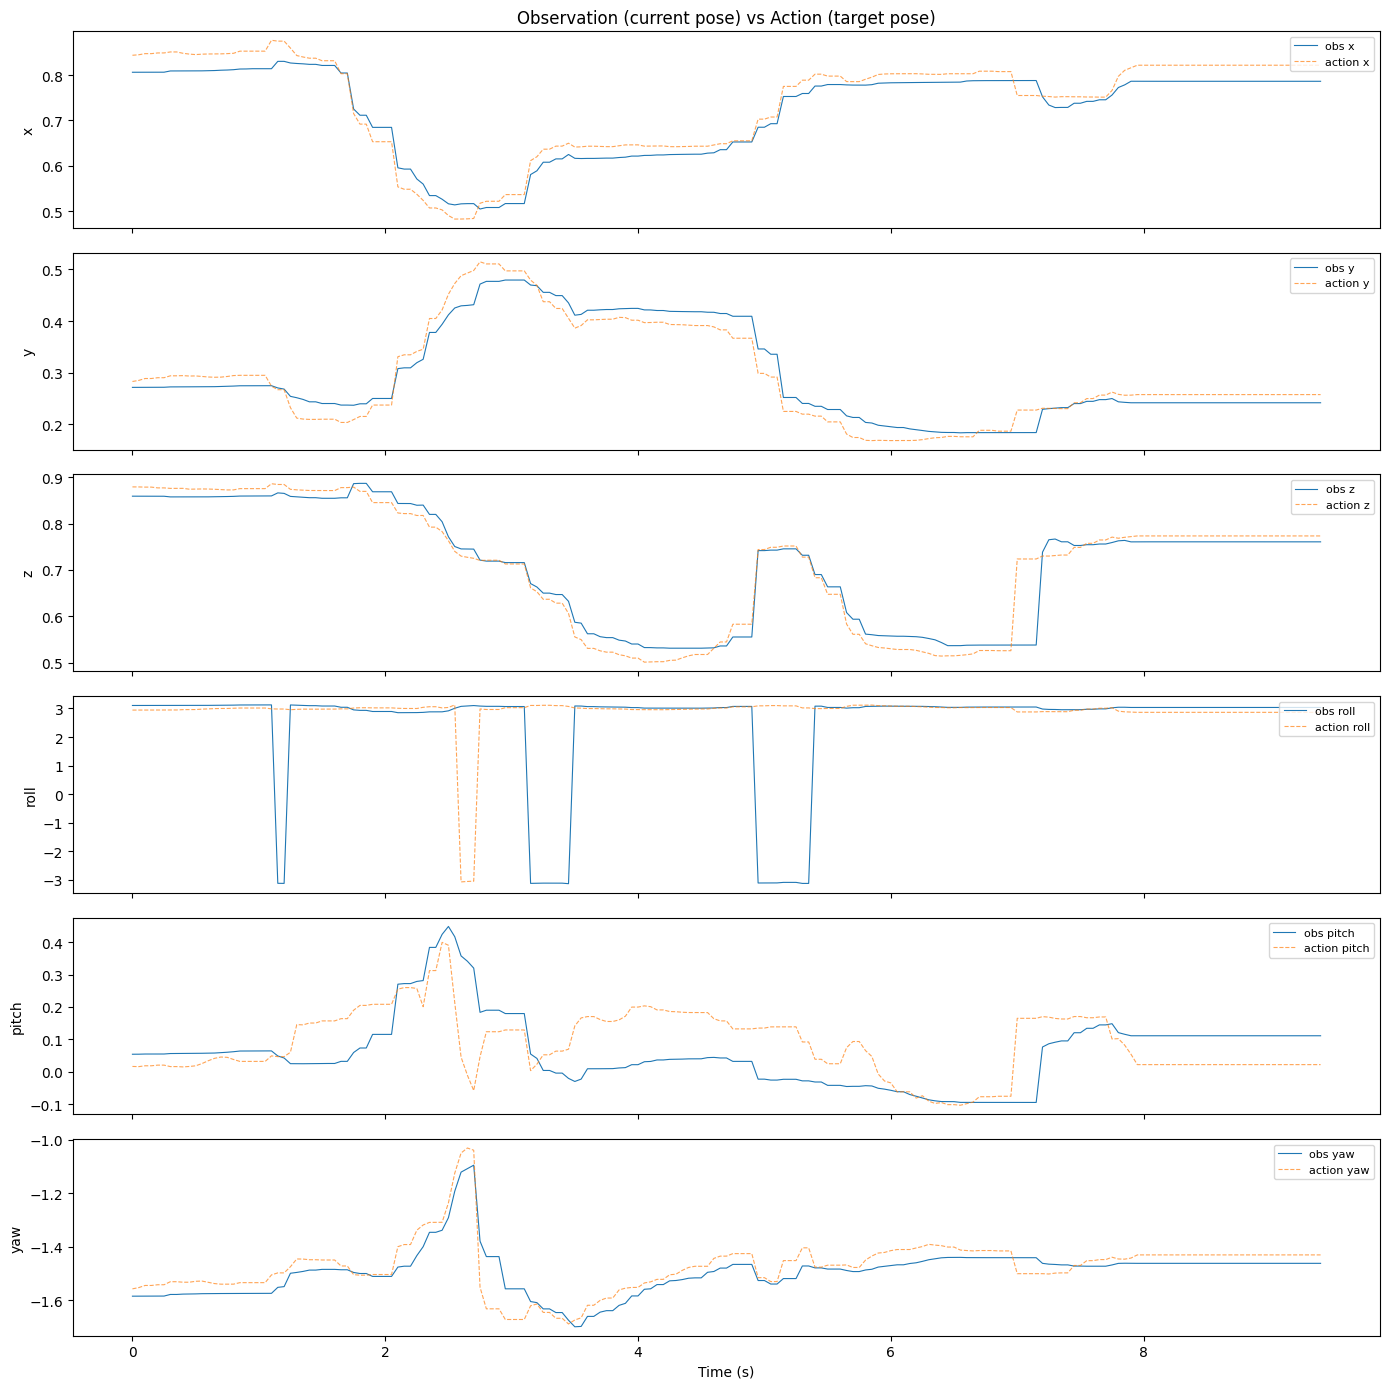

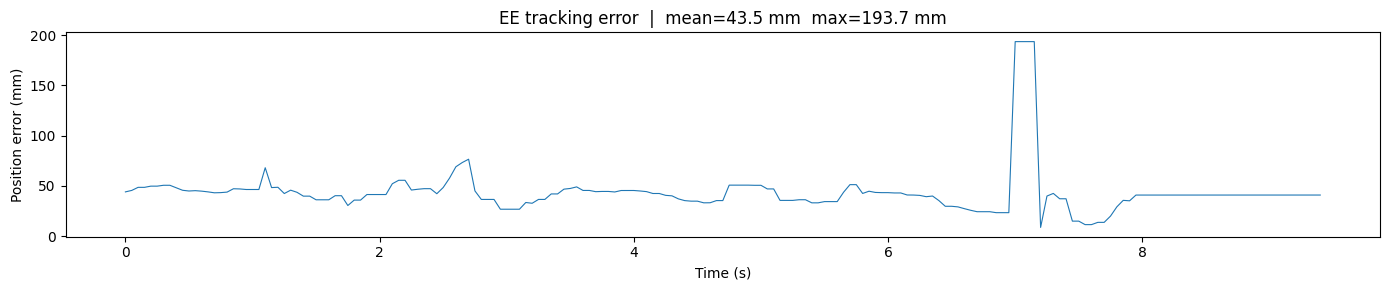

In [11]:
if "observation.state.cartesian" in ep.columns and act_dim >= 7:
    cart = np.stack(ep["observation.state.cartesian"].values)
    labels = ["x", "y", "z", "roll", "pitch", "yaw"]

    fig, axes = plt.subplots(6, 1, figsize=(14, 14), sharex=True)
    for i in range(6):
        axes[i].plot(t, cart[:, i], label=f"obs {labels[i]}", linewidth=0.8)
        axes[i].plot(t, act[:, i], label=f"action {labels[i]}", linewidth=0.8, linestyle="--", alpha=0.7)
        axes[i].set_ylabel(labels[i])
        axes[i].legend(loc="upper right", fontsize=8)
    axes[-1].set_xlabel("Time (s)")
    axes[0].set_title("Observation (current pose) vs Action (target pose)")
    plt.tight_layout()
    plt.show()

    # Tracking error
    pos_err = np.linalg.norm(cart[:, :3] - act[:, :3], axis=1)
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(t, pos_err * 1000, linewidth=0.8)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Position error (mm)")
    ax.set_title(f"EE tracking error  |  mean={pos_err.mean()*1000:.1f} mm  max={pos_err.max()*1000:.1f} mm")
    plt.tight_layout()
    plt.show()
else:
    print("Need both observation.state.cartesian and 7-dim action for overlay")

## 6. Summary stats

In [12]:
print(f"Dataset:   {REPO_ID}")
print(f"Episode:   {EPISODE_IDX}")
print(f"Frames:    {len(ep)}")
print(f"Duration:  {t[-1]:.2f} s")
print(f"FPS (meta): {fps}")
print(f"FPS (actual): {(len(ep)-1) / t[-1]:.1f}")
print(f"dt mean:   {dt.mean():.2f} ms")
print(f"dt std:    {dt.std():.2f} ms")
print()

for col in sorted(ep.columns):
    if col.startswith("observation.state") or col == "action":
        arr = np.stack(ep[col].values)
        print(f"{col:40s}  shape={str(arr.shape):12s}  min={arr.min():+.4f}  max={arr.max():+.4f}  std={arr.std():.6f}")

Dataset:   camera_test_wmocap6
Episode:   0
Frames:    189
Duration:  9.40 s
FPS (meta): 20
FPS (actual): 20.0
dt mean:   50.00 ms
dt std:    0.00 ms

action                                    shape=(189, 7)      min=-3.0739  max=+3.1253  std=1.239733
observation.state                         shape=(189, 12)     min=-3.1368  max=+3.1252  std=1.528181
observation.state.cartesian               shape=(189, 6)      min=-3.1368  max=+3.1252  std=1.379912
observation.state.joints                  shape=(189, 6)      min=-2.0804  max=+2.2179  std=1.601238


## 7. Replay comparison (original recording vs replay observation)

Load the replay log saved by `17_replay_dataset.py` and compare the
observed EE pose during replay against the original recording.

Replay log: episode_0_speed1.0.parquet  |  189 frames
Columns: ['frame_index', 'timestamp', 'replay.cart.x', 'replay.cart.y', 'replay.cart.z', 'replay.cart.roll', 'replay.cart.pitch', 'replay.cart.yaw', 'replay.joint.0', 'replay.joint.1', 'replay.joint.2', 'replay.joint.3', 'replay.joint.4', 'replay.joint.5', 'replay.action.0', 'replay.action.1', 'replay.action.2', 'replay.action.3', 'replay.action.4', 'replay.action.5', 'replay.action.6']


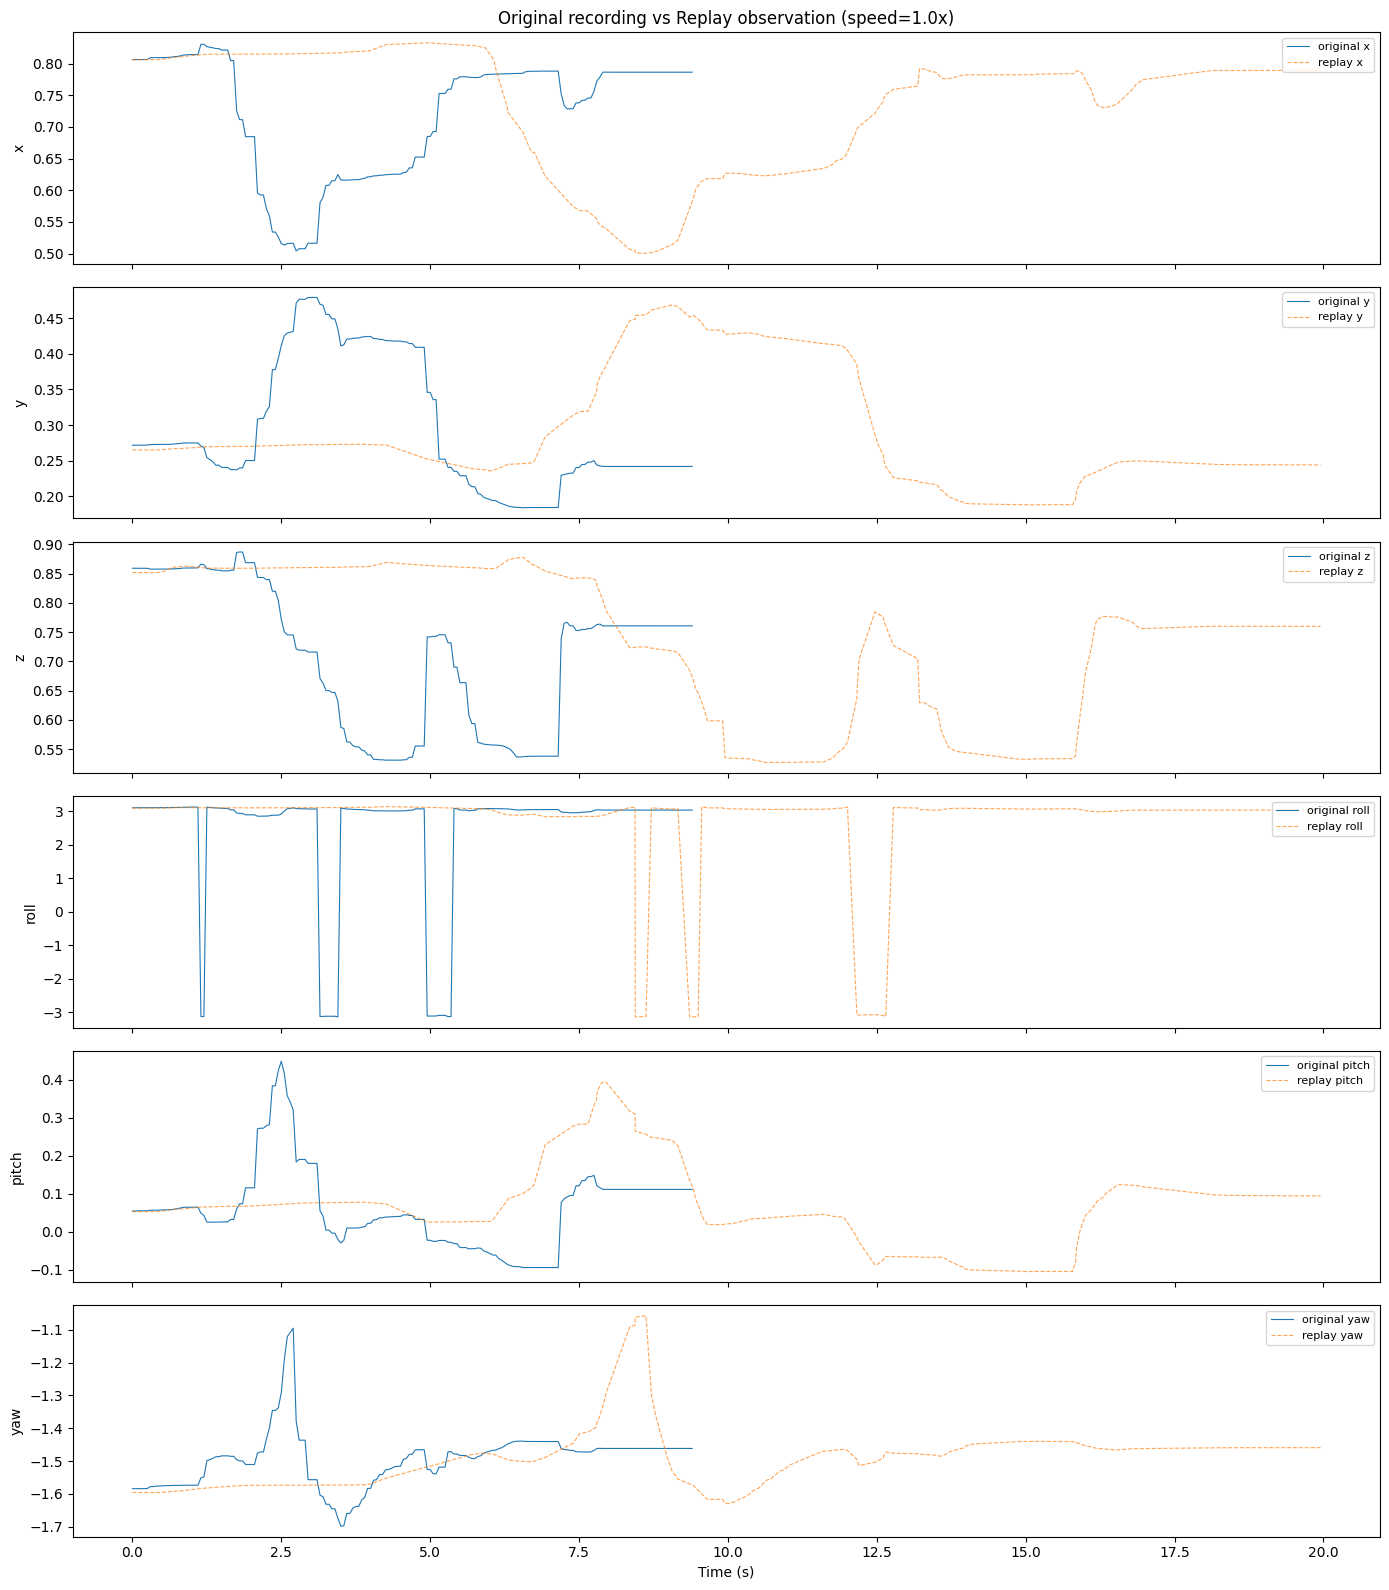

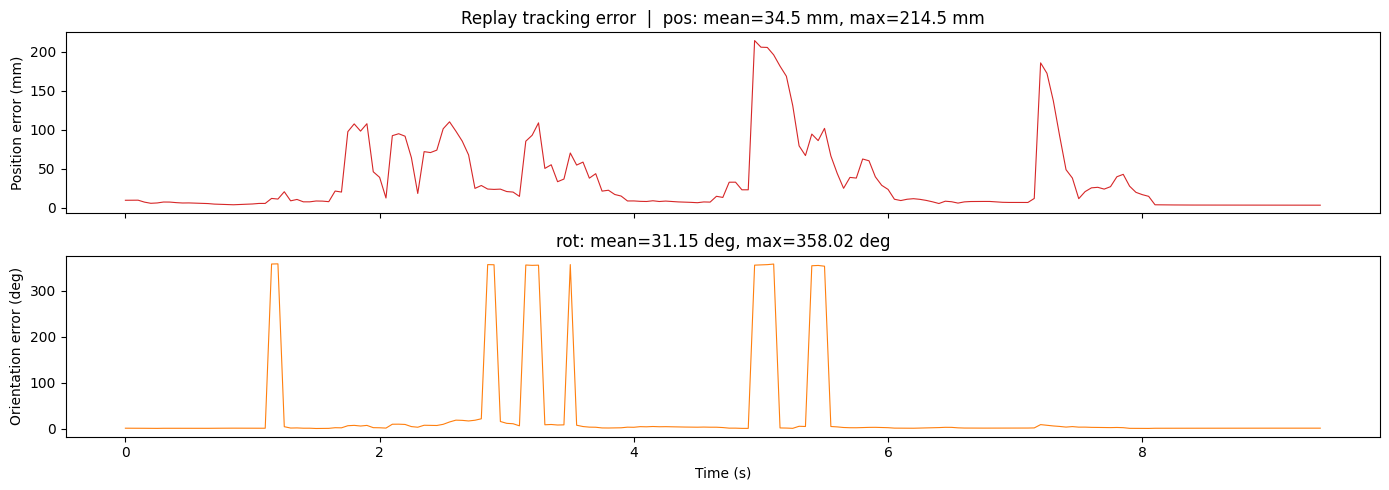

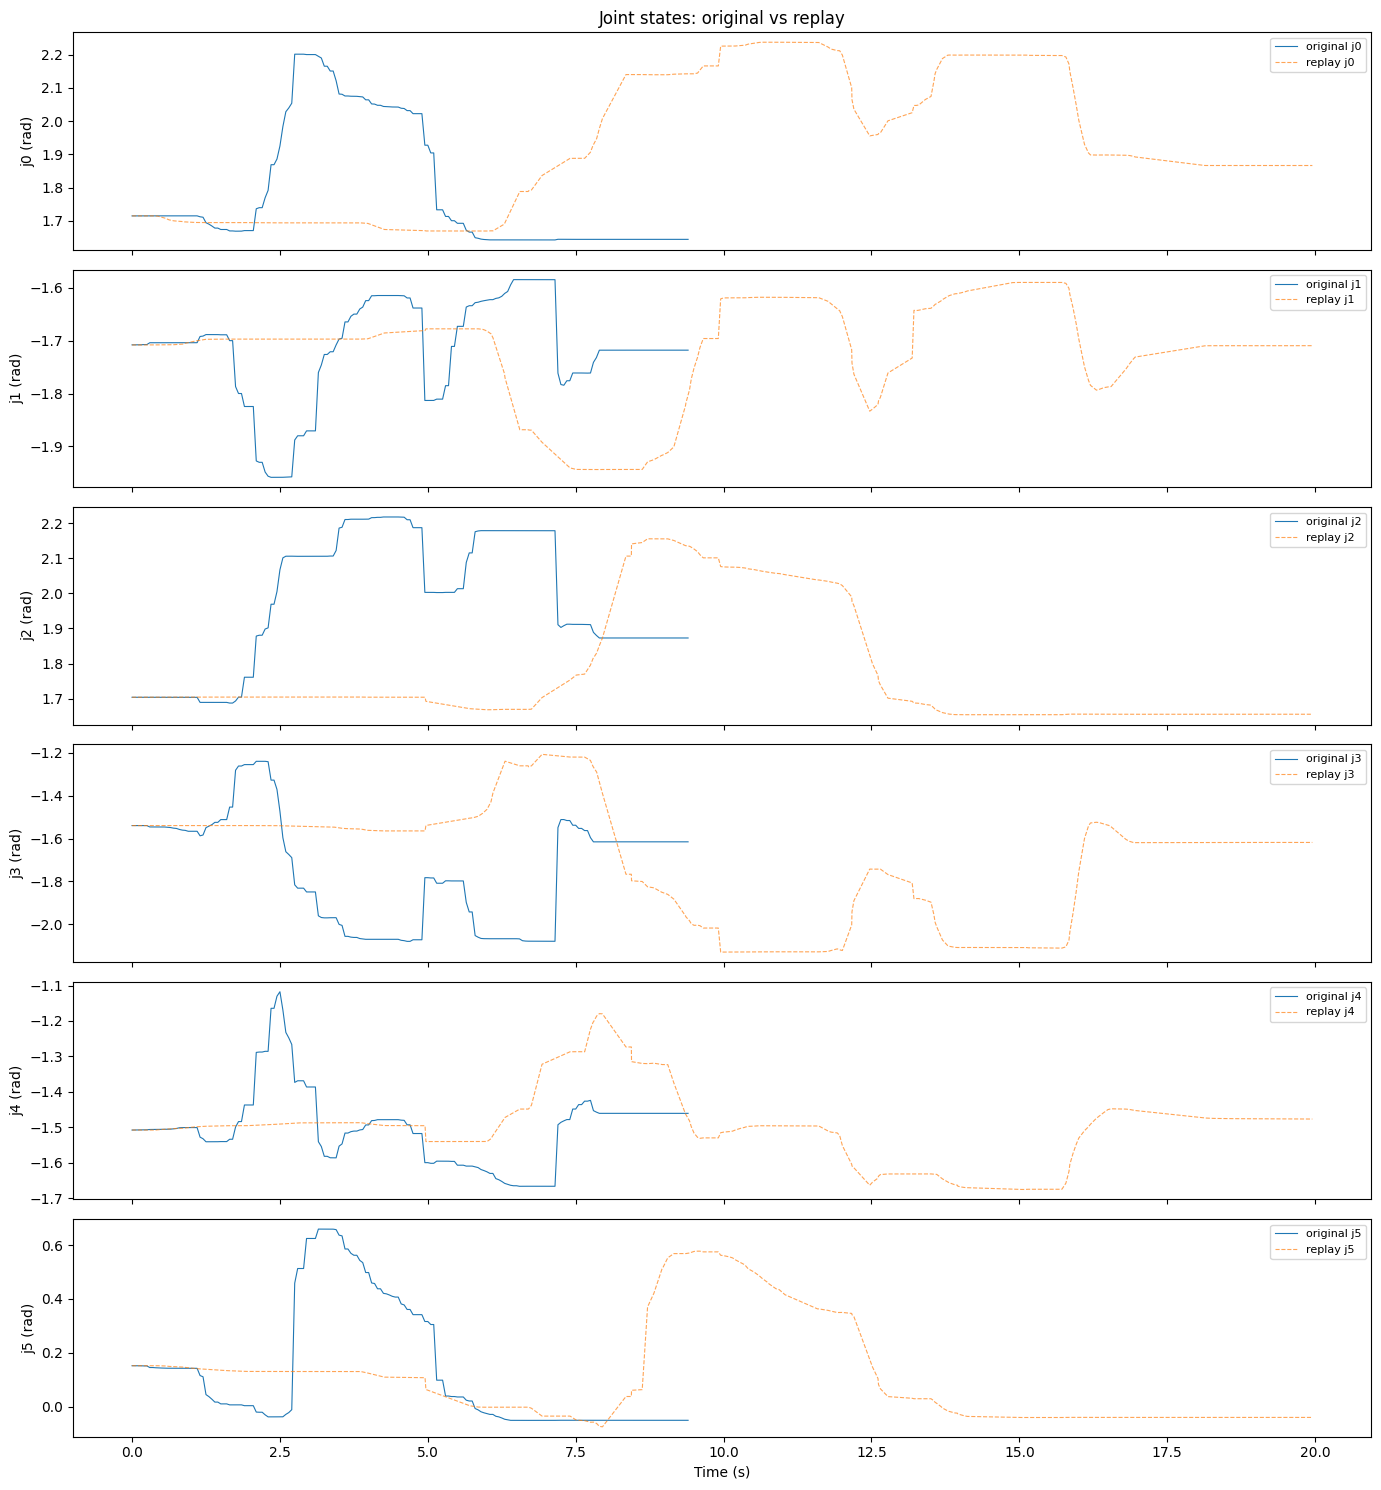


Joint error (rad) per joint:  mean=[0.20333356 0.0304904  0.19106053 0.05749027 0.03205279 0.04070251]  max=[0.5563426  0.18310499 0.5249407  0.48882174 0.23123169 0.47483823]


In [14]:
# ---- Configure replay file ----
REPLAY_SPEED = 1.0  # must match the --speed used during replay
# --------------------------------

replay_path = ds / "replay" / f"episode_{EPISODE_IDX}_speed{REPLAY_SPEED}.parquet"
if not replay_path.exists():
    print(f"No replay log found at {replay_path}")
    print(f"Available replay files: {list((ds / 'replay').glob('*.parquet')) if (ds / 'replay').exists() else []}")
else:
    rp = pd.read_parquet(replay_path)
    print(f"Replay log: {replay_path.name}  |  {len(rp)} frames")
    print(f"Columns: {list(rp.columns)}")

    # Time axes
    rec_t = t[:len(rp)]  # original recording time (truncate if replay is shorter)
    rep_ts = rp["timestamp"].values
    rep_t = rep_ts - rep_ts[0]  # replay time from start

    # --- EE position comparison ---
    cart_cols = [c for c in rp.columns if c.startswith("replay.cart.")]
    if cart_cols and "observation.state.cartesian" in ep.columns:
        orig_cart = np.stack(ep["observation.state.cartesian"].values)[:len(rp)]
        rep_cart = rp[["replay.cart.x", "replay.cart.y", "replay.cart.z",
                        "replay.cart.roll", "replay.cart.pitch", "replay.cart.yaw"]].values
        labels = ["x", "y", "z", "roll", "pitch", "yaw"]

        fig, axes = plt.subplots(6, 1, figsize=(14, 16), sharex=True)
        for i in range(6):
            axes[i].plot(rec_t, orig_cart[:, i], label=f"original {labels[i]}", linewidth=0.8)
            axes[i].plot(rep_t, rep_cart[:, i], label=f"replay {labels[i]}", linewidth=0.8, linestyle="--", alpha=0.7)
            axes[i].set_ylabel(labels[i])
            axes[i].legend(loc="upper right", fontsize=8)
        axes[-1].set_xlabel("Time (s)")
        axes[0].set_title(f"Original recording vs Replay observation (speed={REPLAY_SPEED}x)")
        plt.tight_layout()
        plt.show()

        # Position error
        pos_err = np.linalg.norm(orig_cart[:, :3] - rep_cart[:, :3], axis=1)
        rot_err = np.linalg.norm(orig_cart[:, 3:] - rep_cart[:, 3:], axis=1)

        fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
        axes[0].plot(rec_t, pos_err * 1000, linewidth=0.8, color="tab:red")
        axes[0].set_ylabel("Position error (mm)")
        axes[0].set_title(
            f"Replay tracking error  |  pos: mean={pos_err.mean()*1000:.1f} mm, "
            f"max={pos_err.max()*1000:.1f} mm")

        axes[1].plot(rec_t, np.degrees(rot_err), linewidth=0.8, color="tab:orange")
        axes[1].set_ylabel("Orientation error (deg)")
        axes[1].set_xlabel("Time (s)")
        axes[1].set_title(
            f"rot: mean={np.degrees(rot_err).mean():.2f} deg, "
            f"max={np.degrees(rot_err).max():.2f} deg")
        plt.tight_layout()
        plt.show()
    else:
        print("No cartesian data in replay log or original dataset for comparison")

    # --- Joint comparison ---
    joint_cols = [c for c in rp.columns if c.startswith("replay.joint.")]
    if joint_cols and "observation.state.joints" in ep.columns:
        orig_joints = np.stack(ep["observation.state.joints"].values)[:len(rp)]
        rep_joints = rp[[f"replay.joint.{j}" for j in range(orig_joints.shape[1])]].values

        fig, axes = plt.subplots(orig_joints.shape[1], 1, figsize=(14, 2.5 * orig_joints.shape[1]), sharex=True)
        for i in range(orig_joints.shape[1]):
            axes[i].plot(rec_t, orig_joints[:, i], label=f"original j{i}", linewidth=0.8)
            axes[i].plot(rep_t, rep_joints[:, i], label=f"replay j{i}", linewidth=0.8, linestyle="--", alpha=0.7)
            axes[i].set_ylabel(f"j{i} (rad)")
            axes[i].legend(loc="upper right", fontsize=8)
        axes[-1].set_xlabel("Time (s)")
        axes[0].set_title("Joint states: original vs replay")
        plt.tight_layout()
        plt.show()

        joint_err = np.abs(orig_joints - rep_joints)
        print(f"\nJoint error (rad) per joint:  mean={joint_err.mean(axis=0)}  max={joint_err.max(axis=0)}")
    else:
        print("No joint data in replay log or original dataset for comparison")